# Pulse Width Control in SquareOscillator

The SquareOscillator now supports variable pulse width, allowing you to create
pulse waves with different duty cycles beyond the traditional 50% square wave.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from engine import SquareOscillator

# Set up plotting style
plt.style.use("default")

Example 1: Traditional Square Wave


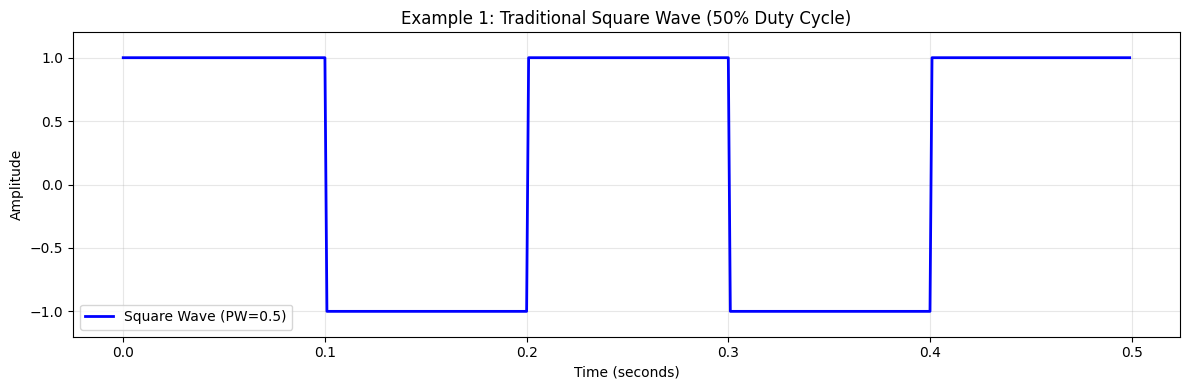

  Pulse width: 0.5 (50% duty cycle)
  Generated 500 samples


In [2]:
# Example 1: Traditional square wave (50% duty cycle)
print("Example 1: Traditional Square Wave")
square_osc = SquareOscillator(
    frequency=5,  # Low frequency for clear visualization
    pulsewidth=0.5,  # 50% duty cycle = traditional square wave
    gain_db=0,  # Unity gain for visualization
    sample_rate=1000,
)

# Generate samples
n_samples = 500
samples = square_osc.get_samples(n_samples)
time = np.arange(n_samples) / 1000  # Time in seconds

# Plot
plt.figure(figsize=(12, 4))
plt.plot(time, samples, "b-", linewidth=2, label="Square Wave (PW=0.5)")
plt.grid(True, alpha=0.3)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Example 1: Traditional Square Wave (50% Duty Cycle)")
plt.ylim(-1.2, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

print("  Pulse width: 0.5 (50% duty cycle)")
print(f"  Generated {len(samples)} samples")

Example 2: Narrow Pulse


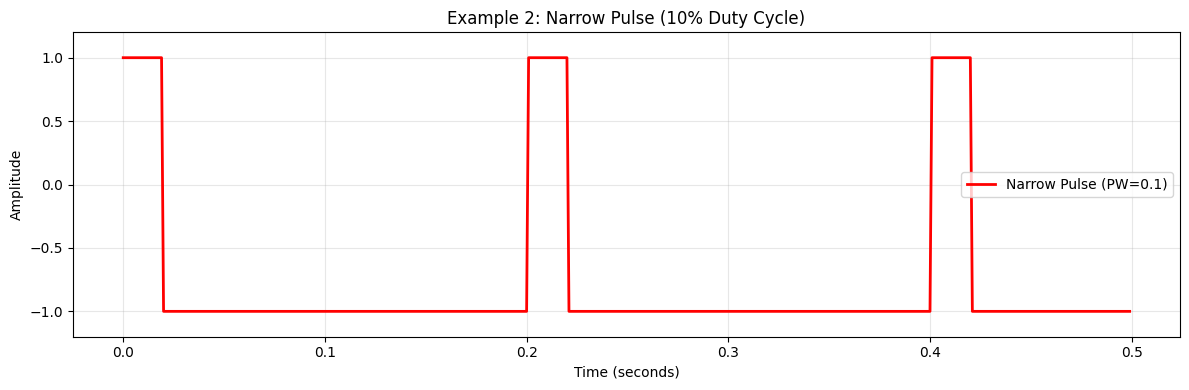

  Pulse width: 0.1 (10% duty cycle)
  Generated 500 samples


In [3]:
# Example 2: Narrow pulse (10% duty cycle)
print("Example 2: Narrow Pulse")
pulse_osc = SquareOscillator(
    frequency=5, pulsewidth=0.1, gain_db=0, sample_rate=1000  # 10% high, 90% low
)

# Generate samples
n_samples = 500
samples = pulse_osc.get_samples(n_samples)
time = np.arange(n_samples) / 1000

# Plot
plt.figure(figsize=(12, 4))
plt.plot(time, samples, "r-", linewidth=2, label="Narrow Pulse (PW=0.1)")
plt.grid(True, alpha=0.3)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Example 2: Narrow Pulse (10% Duty Cycle)")
plt.ylim(-1.2, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

print("  Pulse width: 0.1 (10% duty cycle)")
print(f"  Generated {len(samples)} samples")

Example 3: Wide Pulse


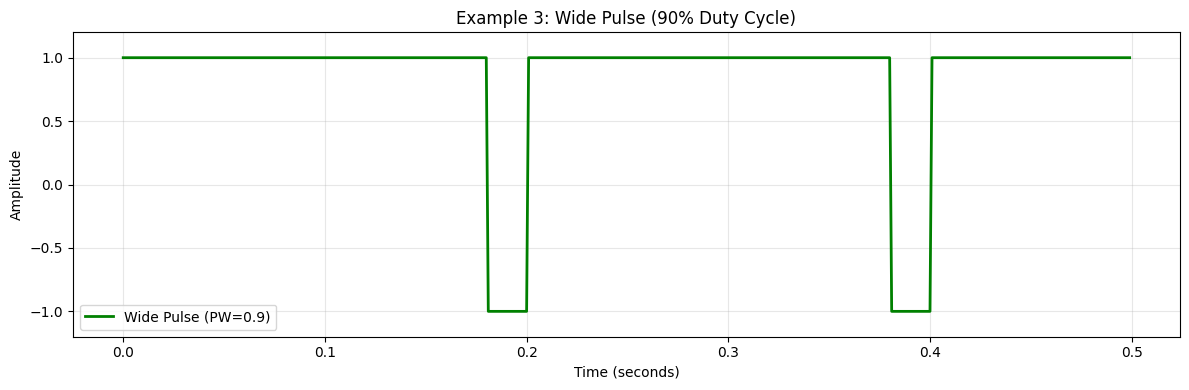

  Pulse width: 0.9 (90% duty cycle)
  Generated 500 samples


In [4]:
# Example 3: Wide pulse (90% duty cycle)
print("Example 3: Wide Pulse")
wide_osc = SquareOscillator(
    frequency=5, pulsewidth=0.9, gain_db=0, sample_rate=1000  # 90% high, 10% low
)

# Generate samples
n_samples = 500
samples = wide_osc.get_samples(n_samples)
time = np.arange(n_samples) / 1000

# Plot
plt.figure(figsize=(12, 4))
plt.plot(time, samples, "g-", linewidth=2, label="Wide Pulse (PW=0.9)")
plt.grid(True, alpha=0.3)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Example 3: Wide Pulse (90% Duty Cycle)")
plt.ylim(-1.2, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

print("  Pulse width: 0.9 (90% duty cycle)")
print(f"  Generated {len(samples)} samples")

Example 4: Pulse Width Comparison


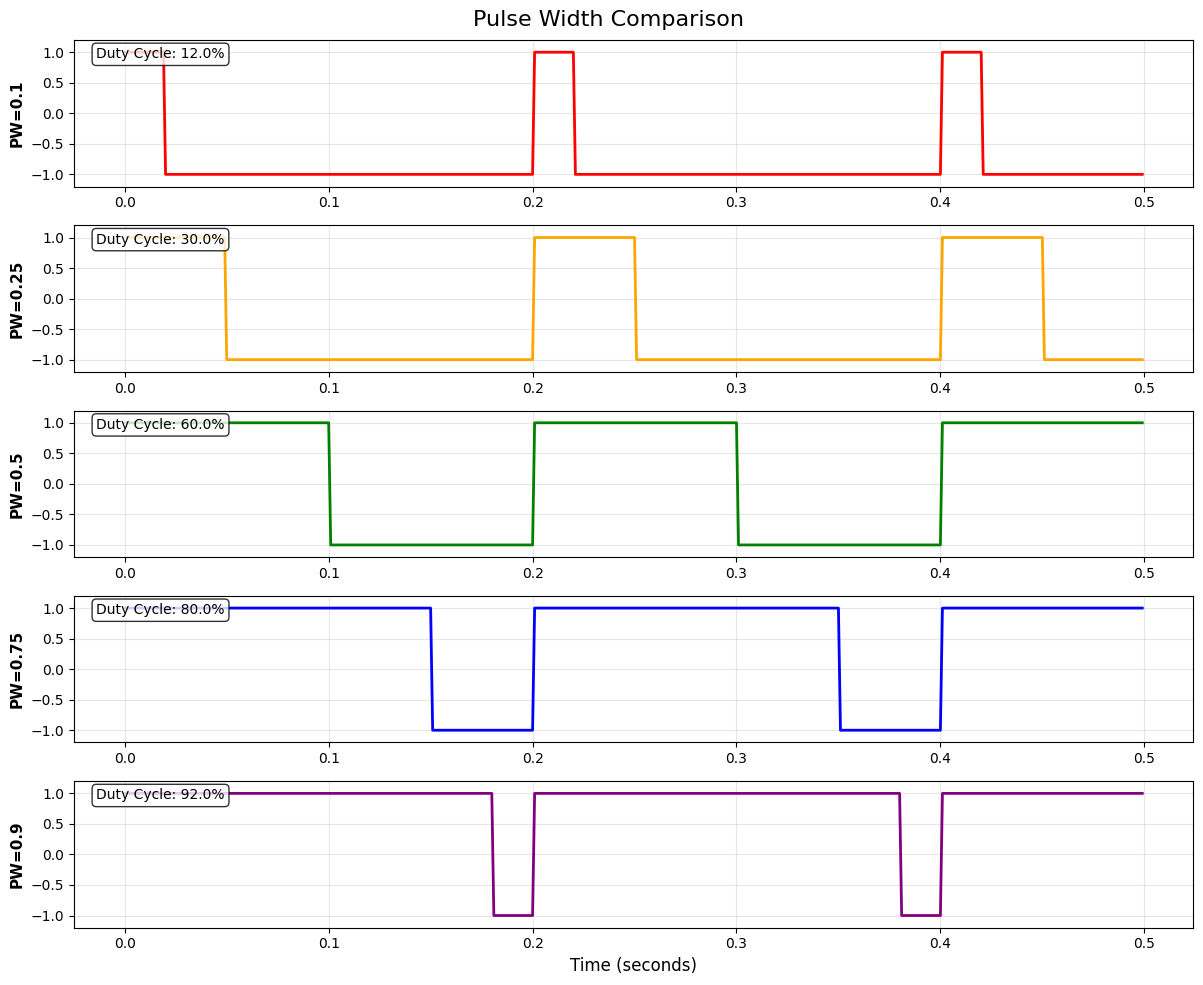

  Displayed comparison of 5 different pulse widths


In [5]:
# Example 4: Comparison of multiple pulse widths
print("Example 4: Pulse Width Comparison")

pulsewidths = [0.1, 0.25, 0.5, 0.75, 0.9]
colors = ["red", "orange", "green", "blue", "purple"]
sample_rate = 1000
n_samples = 500
time = np.arange(n_samples) / sample_rate

fig, axes = plt.subplots(len(pulsewidths), 1, figsize=(12, 10))
fig.suptitle("Pulse Width Comparison", fontsize=16)

for i, (pw, color) in enumerate(zip(pulsewidths, colors, strict=False)):
    osc = SquareOscillator(
        frequency=5, pulsewidth=pw, gain_db=0, sample_rate=sample_rate
    )
    samples = osc.get_samples(n_samples)

    axes[i].plot(time, samples, color=color, linewidth=2)
    axes[i].set_ylabel(f"PW={pw}", fontsize=11, fontweight="bold")
    axes[i].set_ylim(-1.2, 1.2)
    axes[i].grid(True, alpha=0.3)

    # Calculate actual duty cycle
    high_samples = np.sum(samples > 0)
    actual_duty = high_samples / n_samples
    axes[i].text(
        0.02,
        0.95,
        f"Duty Cycle: {actual_duty:.1%}",
        transform=axes[i].transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

axes[-1].set_xlabel("Time (seconds)", fontsize=12)
plt.tight_layout()
plt.show()

print("  Displayed comparison of 5 different pulse widths")

Example 5: Runtime Pulse Width Modulation
  Initial pulsewidth: 0.5
  Changed to pulsewidth=0.1, generated 100 samples
  Changed to pulsewidth=0.3, generated 100 samples
  Changed to pulsewidth=0.5, generated 100 samples
  Changed to pulsewidth=0.7, generated 100 samples
  Changed to pulsewidth=0.9, generated 100 samples


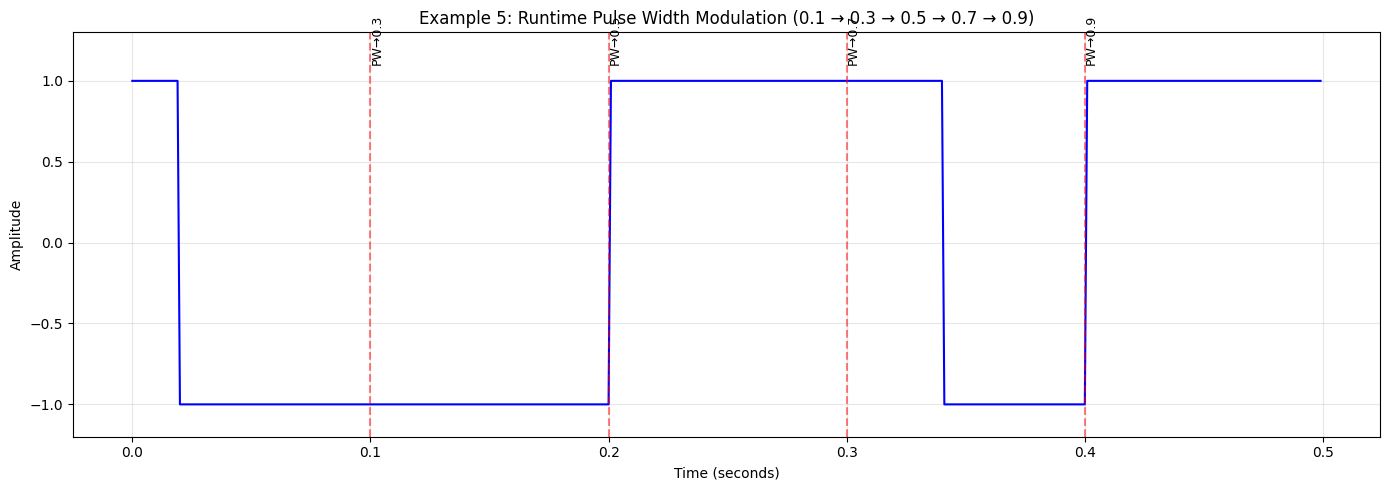

In [6]:
# Example 5: Runtime pulse width modulation
print("Example 5: Runtime Pulse Width Modulation")

osc = SquareOscillator(frequency=5, pulsewidth=0.5, gain_db=0, sample_rate=1000)
print(f"  Initial pulsewidth: {osc.pulsewidth}")

# Generate waveforms with different pulse widths
pulsewidths = [0.1, 0.3, 0.5, 0.7, 0.9]
samples_per_pw = 100
all_samples = []

for pw in pulsewidths:
    osc.pulsewidth = pw
    samples = osc.get_samples(samples_per_pw)
    all_samples.extend(samples)
    print(f"  Changed to pulsewidth={pw}, generated {len(samples)} samples")

# Plot the modulated waveform
time = np.arange(len(all_samples)) / 1000

plt.figure(figsize=(14, 5))
plt.plot(time, all_samples, "b-", linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Example 5: Runtime Pulse Width Modulation (0.1 → 0.3 → 0.5 → 0.7 → 0.9)")

# Add vertical lines to show where pulse width changes
for i, pw in enumerate(pulsewidths[:-1]):
    x_pos = (i + 1) * samples_per_pw / 1000
    plt.axvline(x=x_pos, color="red", linestyle="--", alpha=0.5)
    plt.text(
        x_pos,
        1.1,
        f"PW→{pulsewidths[i+1]}",
        rotation=90,
        verticalalignment="bottom",
        fontsize=9,
    )

plt.ylim(-1.2, 1.3)
plt.tight_layout()
plt.show()

Example 6: Audio Frequency Pulse Waves


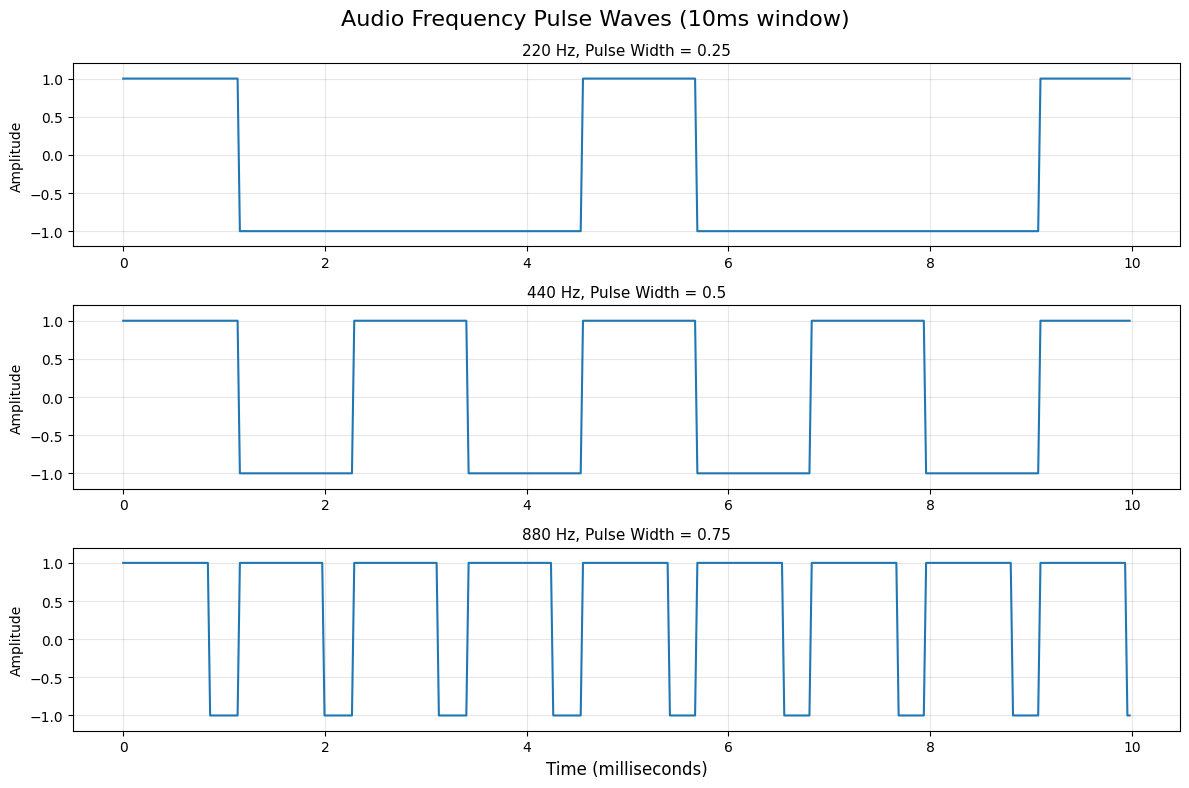

  Generated audio frequency pulse waves at 220 Hz, 440 Hz, and 880 Hz


In [7]:
# Example 6: Audio frequency pulse waves with different widths
print("Example 6: Audio Frequency Pulse Waves")

# Create three oscillators at audio frequencies
frequencies = [220, 440, 880]  # A3, A4, A5
pulsewidths_audio = [0.25, 0.5, 0.75]
sample_rate = 44100
duration = 0.01  # 10ms window
n_samples = int(duration * sample_rate)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle("Audio Frequency Pulse Waves (10ms window)", fontsize=16)

for i, (freq, pw) in enumerate(zip(frequencies, pulsewidths_audio, strict=False)):
    osc = SquareOscillator(
        frequency=freq, pulsewidth=pw, gain_db=0, sample_rate=sample_rate
    )
    samples = osc.get_samples(n_samples)
    time_ms = np.arange(n_samples) / sample_rate * 1000  # Time in milliseconds

    axes[i].plot(time_ms, samples, linewidth=1.5)
    axes[i].set_ylabel("Amplitude", fontsize=10)
    axes[i].set_title(f"{freq} Hz, Pulse Width = {pw}", fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-1.2, 1.2)

axes[-1].set_xlabel("Time (milliseconds)", fontsize=12)
plt.tight_layout()
plt.show()

print("  Generated audio frequency pulse waves at 220 Hz, 440 Hz, and 880 Hz")

Example 7: Complete Parameter Control
  Frequency: 261.63 Hz
  Pulse width: 0.25 (25% duty cycle)
  Gain: -20.0 dB
  Amplitude: 0.100
  Phase: 90°
  Sample rate: 48000 Hz


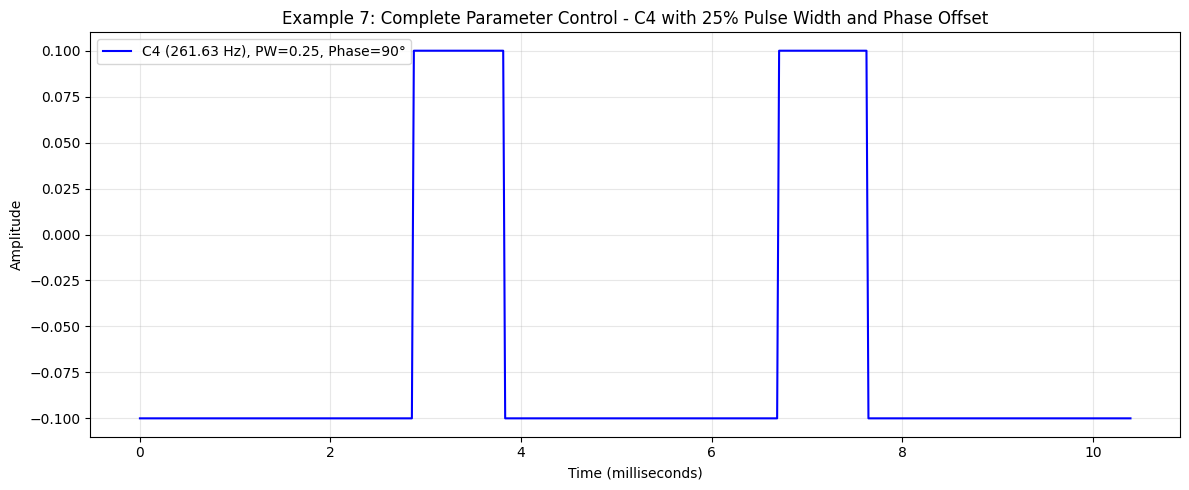


✓ All examples completed successfully!


In [8]:
# Example 7: Complete parameter control
print("Example 7: Complete Parameter Control")

osc = SquareOscillator(
    frequency=261.63,  # C4
    pulsewidth=0.25,  # 25% duty cycle
    gain_db=-20,  # Safe mixing level
    phase=90,  # 90 degree phase offset
    sample_rate=48000,  # High quality sample rate
)

print(f"  Frequency: {osc.frequency} Hz")
print(f"  Pulse width: {osc.pulsewidth} (25% duty cycle)")
print(f"  Gain: {osc.gain_db:.1f} dB")
print(f"  Amplitude: {osc.amplitude:.3f}")
print("  Phase: 90°")
print("  Sample rate: 48000 Hz")

# Generate and plot
n_samples = 500
samples = osc.get_samples(n_samples)
time = np.arange(n_samples) / 48000 * 1000  # Time in milliseconds

plt.figure(figsize=(12, 5))
plt.plot(time, samples, "b-", linewidth=1.5, label="C4 (261.63 Hz), PW=0.25, Phase=90°")
plt.grid(True, alpha=0.3)
plt.xlabel("Time (milliseconds)")
plt.ylabel("Amplitude")
plt.title(
    "Example 7: Complete Parameter Control - C4 with 25% Pulse Width and Phase Offset"
)
plt.legend()
plt.tight_layout()
plt.show()

print("\n✓ All examples completed successfully!")